# problem definition
This project focuses on understanding the data, identifying patterns, and transforming raw features into meaningful representations that can improve future model performance using House Prices - Advanced Regression Techniques.

**Objective**

The main goals of this project are:
  - Understand the distribution and relationships between housing features and SalePrice
  - Identify and handle data quality issues such as missing values and outliers
  - Analyze categorical and numerical variables to uncover meaningful patterns
  - Engineer new features that better capture:
      - Property size and space utilization
      - Quality and condition of the house
      - Location-based effects like neighborhood influence
      - Temporal aspects like house age, remodeling history
      - Interaction effects between features

**dataset**

source from: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

This project uses the Kaggle House Prices dataset, which contains 1460 rows and 81 features describing residential properties in Ames, Iowa. To avoid unnecessary complexity, only the most influential features are considered in the analysis.

**Data dictionary**
- SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.
- MSSubClass: The building class
- MSZoning: The general zoning classification
- LotFrontage: Linear feet of street connected to property
- LotArea: Lot size in square feet
- Street: Type of road access
- Alley: Type of alley access
- LotShape: General shape of property
- LandContour: Flatness of the property
- Utilities: Type of utilities available
- LotConfig: Lot configuration
- LandSlope: Slope of property
- Neighborhood: Physical locations within Ames city limits
- Condition1: Proximity to main road or railroad
- Condition2: Proximity to main road or railroad (if a second is present)
- BldgType: Type of dwelling
- HouseStyle: Style of dwelling
- OverallQual: Overall material and finish quality
- OverallCond: Overall condition rating
- YearBuilt: Original construction date
- YearRemodAdd: Remodel date
- RoofStyle: Type of roof
- RoofMatl: Roof material
- Exterior1st: Exterior covering on house
- Exterior2nd: Exterior covering on house (if more than one material)
- MasVnrType: Masonry veneer type
- MasVnrArea: Masonry veneer area in square feet
- ExterQual: Exterior material quality
- ExterCond: Present condition of the material on the exterior
- Foundation: Type of foundation
- BsmtQual: Height of the basement
- BsmtCond: General condition of the basement
- BsmtExposure: Walkout or garden level basement walls
- BsmtFinType1: Quality of basement finished area
- BsmtFinSF1: Type 1 finished square feet
- BsmtFinType2: Quality of second finished area (if present)
- BsmtFinSF2: Type 2 finished square feet
- BsmtUnfSF: Unfinished square feet of basement area
- TotalBsmtSF: Total square feet of basement area
- Heating: Type of heating
- HeatingQC: Heating quality and condition
- CentralAir: Central air conditioning
- Electrical: Electrical system
- 1stFlrSF: First Floor square feet
- 2ndFlrSF: Second floor square feet
- LowQualFinSF: Low quality finished square feet (all floors)
- GrLivArea: Above grade (ground) living area square feet
- BsmtFullBath: Basement full bathrooms
- BsmtHalfBath: Basement half bathrooms
- FullBath: Full bathrooms above grade
- HalfBath: Half baths above grade
- Bedroom: Number of bedrooms above basement level
- Kitchen: Number of kitchens
- KitchenQual: Kitchen quality
- TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)
- Functional: Home functionality rating
- Fireplaces: Number of fireplaces
- FireplaceQu: Fireplace quality
- GarageType: Garage location
- GarageYrBlt: Year garage was built
- GarageFinish: Interior finish of the garage
- GarageCars: Size of garage in car capacity
- GarageArea: Size of garage in square feet
- GarageQual: Garage quality
- GarageCond: Garage condition
- PavedDrive: Paved driveway
- WoodDeckSF: Wood deck area in square feet
- OpenPorchSF: Open porch area in square feet
- EnclosedPorch: Enclosed porch area in square feet
- 3SsnPorch: Three season porch area in square feet
- ScreenPorch: Screen porch area in square feet
- PoolArea: Pool area in square feet
- PoolQC: Pool quality
- Fence: Fence quality
- MiscFeature: Miscellaneous feature not covered in other categories
- MiscVal: $Value of miscellaneous feature
- MoSold: Month Sold
- YrSold: Year Sold
- SaleType: Type of sale
- SaleCondition: Condition of features

**Challenges:**
- The dataset presents several challenges that require careful preprocessing:
     - Skewed distributions in variables like SalePrice, LotArea, and GrLivArea
     - Outliers that may distort analysis and feature relationships
     - Missing values in features such as LotFrontage and garage-related variables
     - High-cardinality categorical features like Neighborhood
     - Imbalanced categories where some groups have very few observations
     - Multicollinearity among numerical features

# Import neccessary module

Python provides a wide range of modules but I imported only the modules that were necessary for this particular dataset problem

In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
pd.set_option('display.max_columns', None)

In [372]:
# load the dataset into pandas
train=pd.read_csv("house-price.csv")

# inspection

In [373]:
# First 5 elements
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


* Dataset successfully loaded into a DataFrame.
* It displays the first few rows, helping me understand the structure of the data
* each row and column represents a single residential property in Ames, Iowa.

In [374]:
# Last 5 elements
train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [375]:
# column information
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

* have 37 numerical and 43 categorical variables
* several columns have missing values. Alley, PoolQC, MiscFeature,Fence are almost all are miss
  
**Decision:** Identify columns with missing values

In [376]:
# add missing values in each columns from highest to lowest
train.isnull().sum().sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [377]:
# let's compare by calculating percentage
missing = train.isnull().sum().sort_values(ascending=False)
percent = (missing / len(train))*100
data = pd.concat([missing, percent], axis=1, keys=['missing', 'Percent'])
data.iloc[:20] # The first 20 missing values

,missing,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageYrBlt,81,5.547945
GarageCond,81,5.547945
GarageType,81,5.547945


**Observation:**  

- High missingness in: `PoolQC`, `MiscFeature`, `Alley`, `Fence`  
- Moderate missingness: MasVnrType, LotFrontage, Garage features  
- Low missingness: like `Electrical` with 1 missing ,`MasVnrArea` with 8 missing. 
- `SalePrice`, `ExterQual`,`Exterior2nd`, `Exterior1st`, `RoofMatlhas` no missing values.

**Insight:**  

- Sparse features may be dropped or encoded.  
- Moderate missingness can be imputed (median for numerical, mode for categorical).  

**Decision:**
* need to check if missingnes is random or systematic

In [378]:
#statics of numerical feature
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**Observation:** 

- `LotArea` ranges widely from 1300 to 215,245.  
- `OverallQual` ranges from 1 to 10, with a mean of ~6.1.  
- `YearBuilt` spans from 1872 to 2010, showing houses of very different ages.
- `GrLivArea` ranges from 334 to 5642 sq ft  

**Insight:** 

- Large variation and outliers may skew models.  
- Quality and size features strongly influence SalePrice.  

**Decision:**  

- Normalize skewed numerical features.
- Handle outliers.


# Data cleaning

In [379]:
# check if we have duplicated
train.duplicated().sum()

np.int64(0)

No duplicate records. so, Each house entry is unique

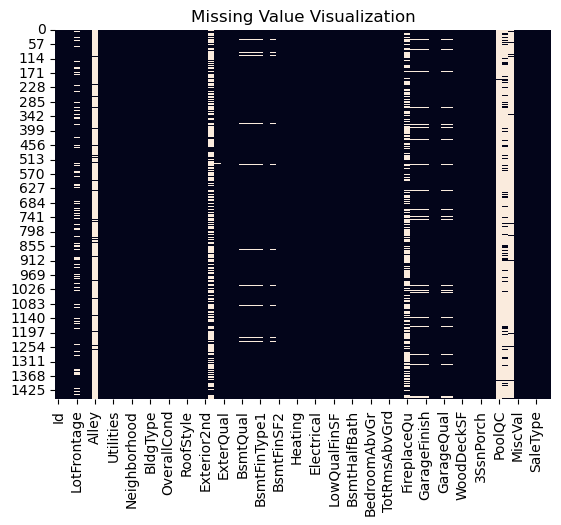

In [380]:
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Value Visualization")
plt.show()

**Observation** ome features show **wide bars**, meaning they have a large number of missing entries compared to others.

**Insight** 

The width of each bar is proportional to the count of NaN values.  
* Wide bars highlight features with significant missingness.  
*  Narrow bars indicate features with few or no missing values.

**Decision** 

- Treat wide‑bar features with structural missingness as *absence* and encode explicitly.  
- For features where missingness is measurement error impute with median or mode.

In [381]:
train.groupby(train['PoolQC'].isnull())['SalePrice'].mean()

PoolQC
False    288138.571429
True     180404.663455
Name: SalePrice, dtype: float64

**observation:** 
* non-missing differ significantly so, missingness is **not random**
* houses without a pool have higher average sale price than houses with a pool.

**insight:**
* having a pool is not the main driver of price in this dataset.
* They occur because many houses lack pools.

**decision:** drop `PoolQC` column

In [382]:
# drop PoolQC column
train.drop("PoolQC",axis=1,inplace=True)

In [383]:
"PoolQC" in train.columns

False

**Successfuly droped the `PoolQC` column**

In [384]:
train.groupby(train['Alley'].isnull())['SalePrice'].mean()

Alley
False    142845.912088
True     183452.131483
Name: SalePrice, dtype: float64

**Observation**

* houses without an alley (missing) have mean saleprice ~183,452
* house has an alley (non-missing) mean saleprice ~ 142,846
*  Missing values are common in `Alley`
  
**insight**
  
* missingness is not at random so, it may be informative. 
* This suggests alley presence is linked to specific property types or neighborhoods, and absence itself is predictive.
    
**decision**  encode missingness explicitly.

In [385]:
train['HasAlley'] = train['Alley'].notnull().astype(int)
train['Alley'] = train['Alley'].fillna('NoAlley')

In [386]:
train["Alley"].isnull().sum()

np.int64(0)

**This manual checking is so complex and not worth me so let's automate**

In [387]:
lst = []

for i in train.columns:
    if train[i].isnull().sum() > 0:
        group = train.groupby(train[i].isnull())['SalePrice'].mean()
        
        if len(group) == 2:
            difference = abs(group[True] - group[False])
            
            lst.append({
                'column': i,
                'missing_mean': group[True],
                'not_missing_mean': group[False],
                'difference': difference
            })

results = pd.DataFrame(lst).sort_values(by='difference', ascending=False)

results

,column,missing_mean,not_missing_mean,difference
10,GarageType,103317.283951,185479.511240,82162.227289
11,GarageYrBlt,103317.283951,185479.511240,82162.227289
12,GarageFinish,103317.283951,185479.511240,82162.227289
13,GarageQual,103317.283951,185479.511240,82162.227289
14,GarageCond,103317.283951,185479.511240,82162.227289
3,BsmtQual,105652.891892,182878.277583,77225.385691
4,BsmtCond,105652.891892,182878.277583,77225.385691
6,BsmtFinType1,105652.891892,182878.277583,77225.385691
9,FireplaceQu,141331.482609,216397.692208,75066.209599
5,BsmtExposure,107938.342105,182871.511252,74933.169146


**Observation**

* Garage-related features show a consistent mean SalePrice difference of about 82,162.
* Basement-related features show a consistent difference of about 77,225.
* `FireplaceQu` shows a difference of about 75,066.
* `MasVnrType` and `MasVnrArea` differences range from 55,869–59,499.
* `MiscFeature` difference ~30,422.
* `Fence` difference ~34,684.
* `Electrical` difference ~13,430.
* `LotFrontage` difference ~849.
  
**Insight**
  
* These differences indicate that missingness is not random.
* The magnitude of the difference reflects the value contribution of the feature: garages and basements add the largest premiums, while features like LotFrontage or Electrical have minimal impact.
* Consistency across related features suggests that missingness is structural (MNAR) and should be treated as meaningful rather than noise.

**decision** 

* Encode structural missingness explicitly
* Impute `Electrical` with mode and `LotFrontage` with median

In [388]:
train['GarageType'].value_counts()

GarageType
Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: count, dtype: int64

In [389]:
train['HasGarage'] = train[['GarageYrBlt','GarageCond','GarageType','GarageFinish','GarageQual']].isnull().any(axis=1).astype(int)

In [390]:
# create  hasgarage  indicator and imputing garage related column with nogarage

garage_cols = ['GarageType','GarageFinish','GarageQual','GarageCond']
train[garage_cols] = train[garage_cols].fillna('NoGarage')

train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)

missing together it shows Structural Missing Features

In [391]:
# imputing basement related columns
train['HasBasement'] = train['BsmtQual'].notnull().astype(int)

bsmt_cols = ['BsmtQual','BsmtCond','BsmtFinType1','BsmtFinType2','BsmtExposure']
train[bsmt_cols] = train[bsmt_cols].fillna('NoBasement')

In [392]:
# impute FireplaceQu

train['HasFireplace'] = train['FireplaceQu'].notnull().astype(int)
train['FireplaceQu'] = train['FireplaceQu'].fillna('NoFireplace')

In [393]:
train['MasVnrArea'].skew()

np.float64(2.669084210182863)

right‑skewness

In [394]:
# impute MasVnrArea
train['HasMasVnr'] = train['MasVnrArea'].notnull().astype(int)
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)


In [395]:
# impute MasVnrType
train['MasVnrType'] = train['MasVnrType'].fillna('None')

In [396]:
train['Fence'] = train['Fence'].fillna('NoFence')
train['MiscFeature'] = train['MiscFeature'].fillna('None')

In [397]:
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

In [398]:
train['LotFrontage_missing'] = train['LotFrontage'].isnull().astype(int)
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())

In [399]:
train.isnull().sum().sum()

np.int64(0)

**All missingness are handled successfuly**

# EDA

In [400]:
# defined catagorical and numerical features for simplicity to  see which feature is catagorical for later used
catagorical=train.select_dtypes(include="object").columns
numerical=train.select_dtypes(exclude="object").columns

## Target variable analysis

In [401]:
# summary of target variable
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

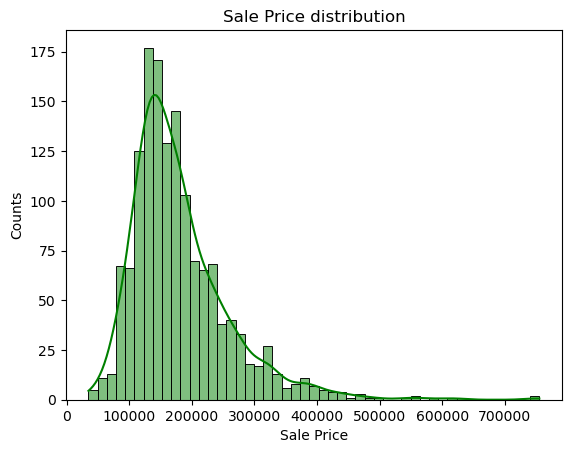

In [402]:
sns.histplot(train["SalePrice"], kde=True,color="g")
plt.title("Sale Price distribution")
plt.xlabel("Sale Price")
plt.ylabel("Counts")
plt.show()

**Observation**
  
* Right-skewed distribution
* Most houses are concentrated between 100,000–250,000 saleprice.
* Fewer houses are sold at higher prices, with a long tail extending up to ~700,000.

**insight**

* SalePrice is not normally distributed.
* small number of luxury properties disproportionately stretch the distribution.

**decision:** Apply a log transformation 

In [403]:
# Skewness and Kurtosis of SalePrice

print("Skewness: %f" % train['SalePrice'].skew())
print("Kurtosis: %f" % train['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


this calculation approves that saleprice is positively skewed and  the distribution is leptokurtic. meaning it has heavy tails and more extreme values compared to a normal distribution.

## univariate analysis

In [404]:
# numerical columns
numerical

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'HasAlley', 'HasGarage',
       'HasBasement', 'HasFireplace', 'HasMasVnr', 'LotFrontage_missing'],
      dtype='object')

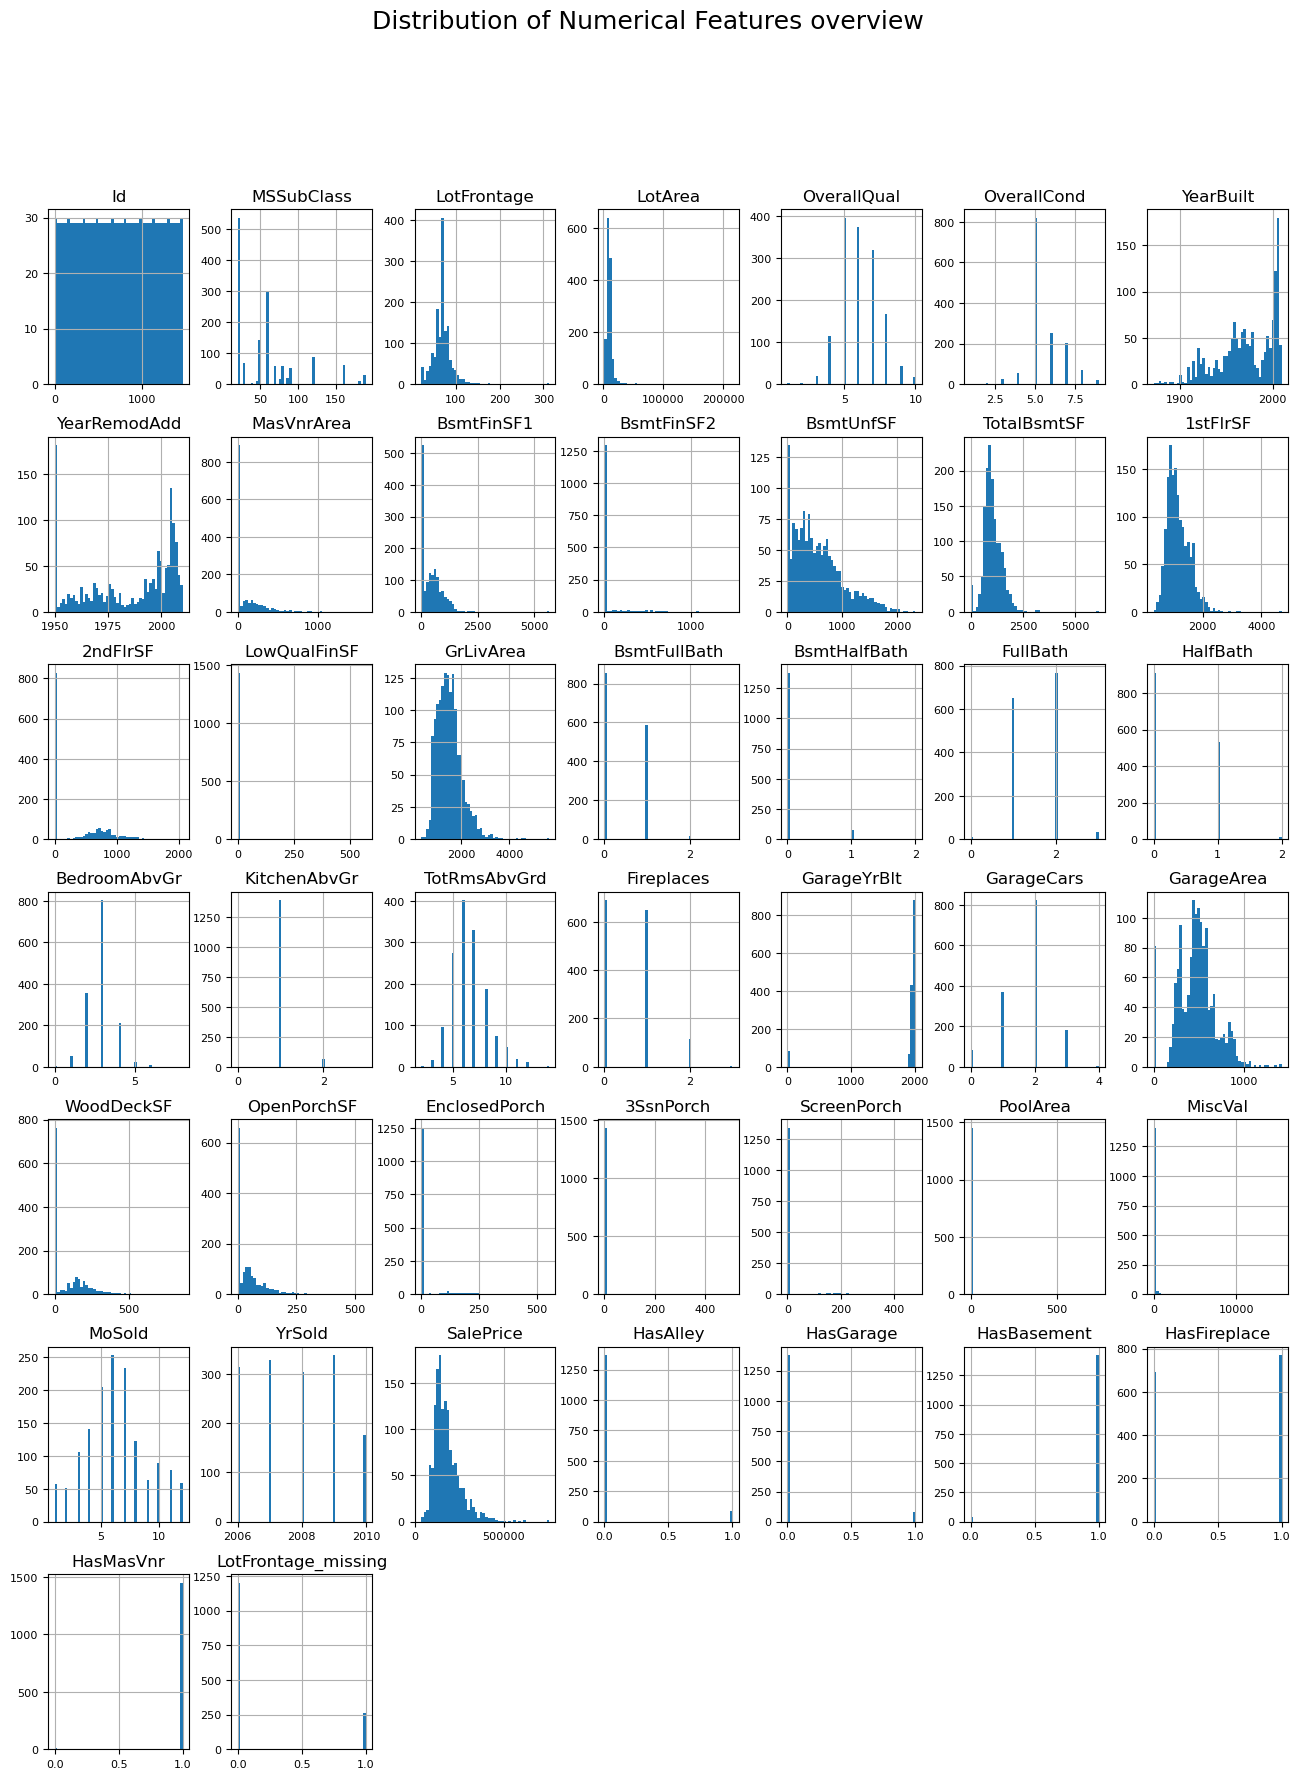

In [405]:
# change in to datafrme
numerical = train.select_dtypes(include=['int64','float64'])

# plot histograms for all numerical features
numerical.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)
plt.suptitle("Distribution of Numerical Features overview",fontsize=18)
plt.show()


**Observation**  
- Some features like LotArea, GrLivArea are **right‑skewed** with long tails.  
- Others like OverallQual, OverallCond are more **discrete/categorical‑like**, showing clustered values.  
- Certain features like YearBuilt, YearRemodAdd show **historical trends**, with concentrations in specific time periods.  
- Outliers are visible in variables like LotArea and MasVnrArea.

**Insight**  
- Skewed distributions indicate the need for **transformations** to stabilize variance.  
- Discrete features like OverallQual behave more like **ordinal categories** than continuous variables.  
- Outliers in LotArea, MasVnrArea, and GrLivArea may distort models if not handled carefully.  
- Year‑related features capture **temporal patterns** in housing development, which can be predictive.

**Decision**  
- Apply log transformations to highly skewed variables.   
- handling of extreme outliers using winsorization or robust models.  
- Retain year features as they provide important historical context for house prices.


In [406]:
# catagorical features
catagorical

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object')

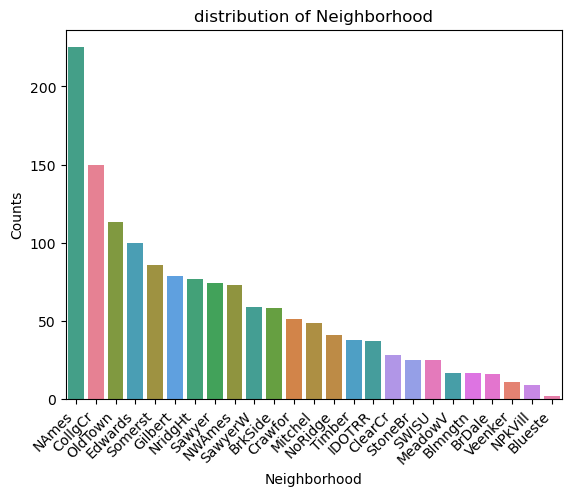

In [407]:
# neighborhood distribution

order = train["Neighborhood"].value_counts().index

sns.countplot(data=train,x='Neighborhood',order=order,hue="Neighborhood")
plt.title("distribution of Neighborhood")
plt.xlabel('Neighborhood')
plt.ylabel('Counts')
plt.xticks(rotation=45, ha='right')
plt.show()

The dataset shows 24 neighborhoods.

- NAmes is the most frequent neighborhood, with counts above 200.
- Other dominant neighborhoods include CollgCr, OldTown, Edwards, Somerst, Gilbert, and NridgHt.
- Several neighborhoods are rare, such as Blueste, NPkVill, BrDale, and MeadowV, each with fewer than 20 observations.
- Several neighborhoods are rare, such as Blueste, NPkVill, BrDale, and MeadowV, each with fewer than 20 observations.
- The distribution is highly imbalanced a few neighborhoods dominate, while many have very small representation.

**Insight**
- Location is a critical driver of house prices, so Neighborhood is one of the most predictive categorical features.
- However, the imbalance means rare neighborhoods may not provide stable signals for modeling.
- Rare categories can introduce noise or overfitting if left unmerged.
- Dominant neighborhoods NAmes, CollgCr will heavily influence model learning, while rare ones may be ignored unless grouped.

**Decision**
- Keep Neighborhood as a key categorical feature it encodes location effects strongly.
- Group rare neighborhoods those with <20 observations into an Other category to reduce sparsity.
- target encoding for Neighborhood to capture its predictive power without exploding dimensionality.

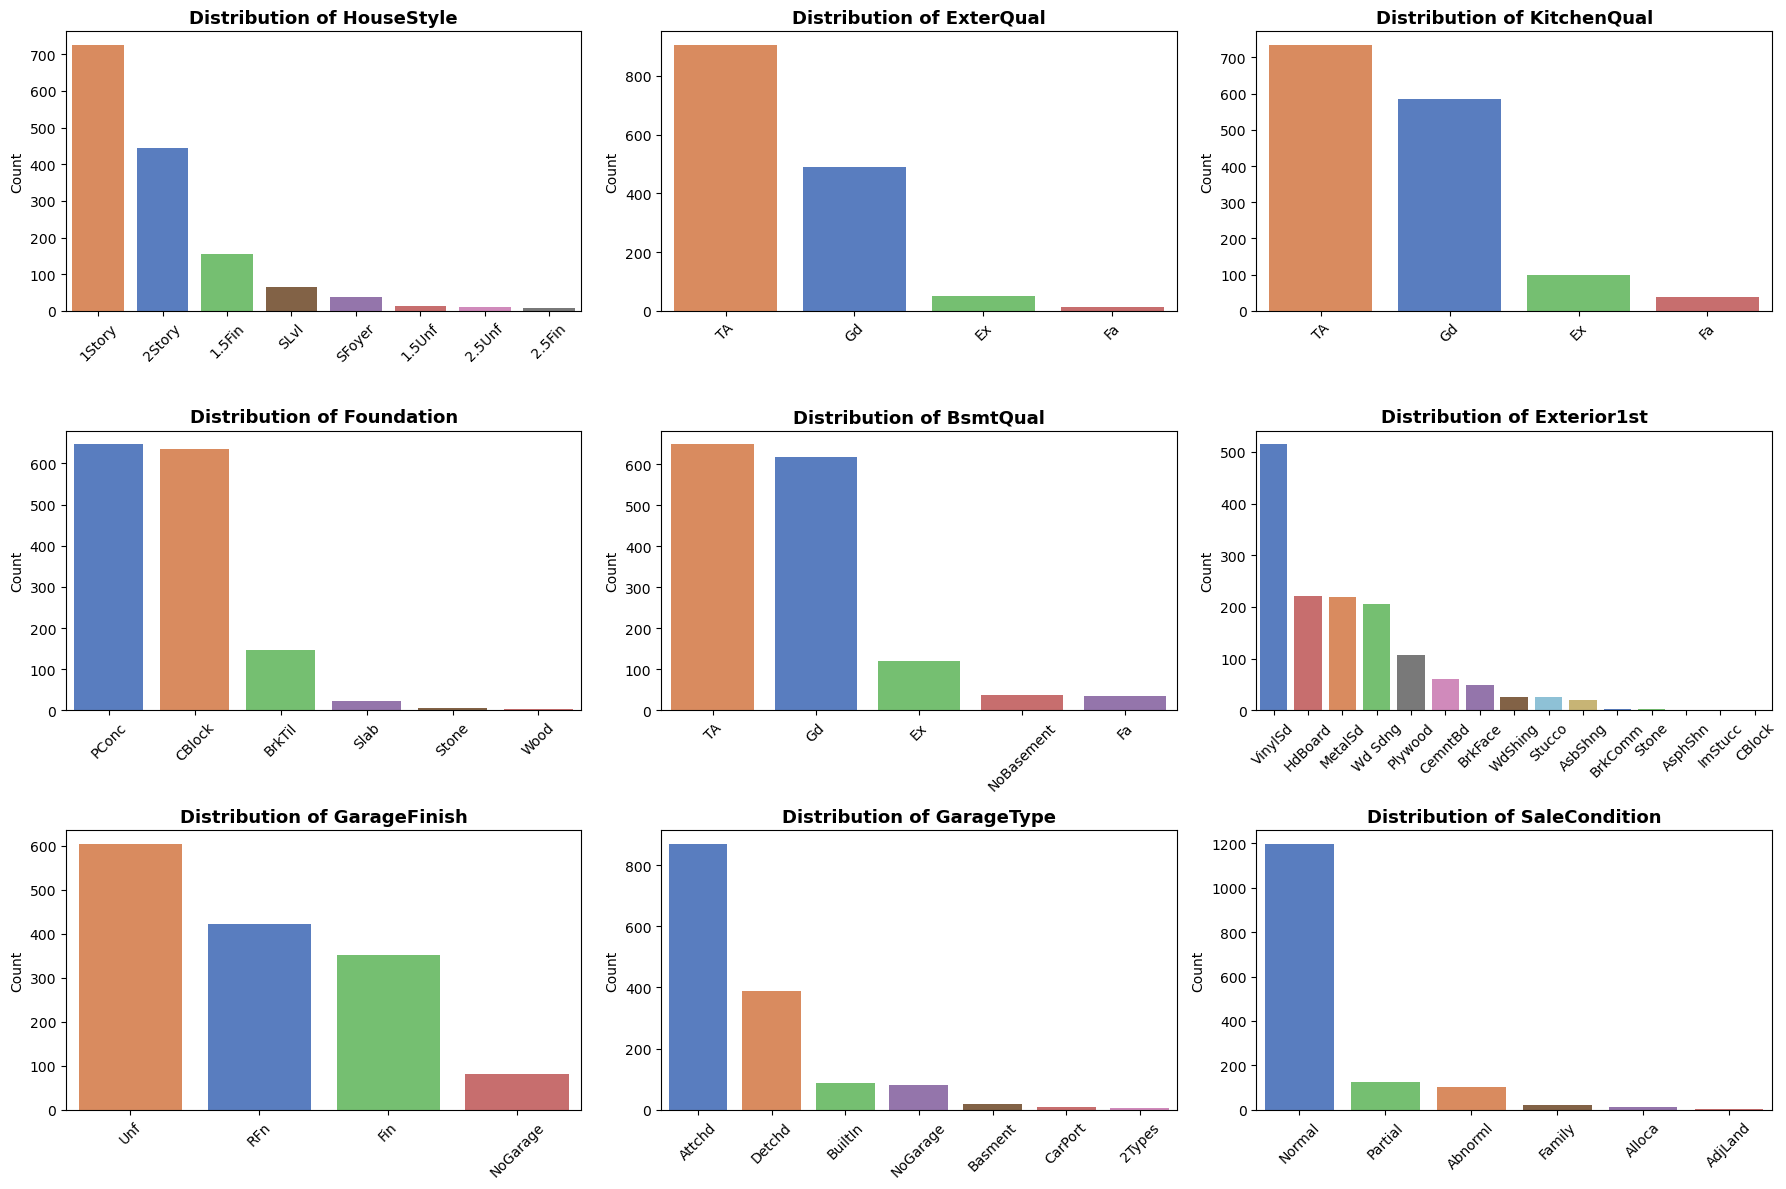

In [408]:
cat_features1 = ['HouseStyle','ExterQual','KitchenQual','Foundation','BsmtQual',
                'Exterior1st','GarageFinish','GarageType','SaleCondition']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,12))
axes = axes.flatten()

for i, col in enumerate(cat_features1):
    ax = axes[i]
    order = train[col].value_counts(dropna=False).index
    
    sns.countplot(data=train, x=col, order=order, palette="muted", ax=ax,hue=col, legend=False)
    ax.set_title(f'Distribution of {col}', fontsize=13, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
# Adjust layout
plt.tight_layout()
plt.show()


**Observation**
- HouseStyle: Dominated by 1Story and 2Story homes; other styles are rare.
- ExterQual & KitchenQual: Most properties rated “Typical/Average (TA)” or “Good (Gd)”; very few “Excellent (Ex)” or “Fair (Fa)”.
- Foundation: PConc and CBlock are the most common; others like Stone/Wood are negligible.
- BsmtQual: Majority are TA or Gd; very few Ex or Fa.
- Exterior1st: Vinyl siding is the most frequent, followed by other materials like HdBoard and MetalSd.
- GarageFinish: Unfinished (Unf) and Rough Finished (RFn) dominate; fully finished garages are less common.
- GarageType: Attached garages are most frequent; detached and other types are less common.
- SaleCondition: Normal sales dominate; abnormal, partial, or family-related sales are rare.

**Insight**
- Buyers overwhelmingly prefer standard 1–2 story homes with average or good quality finishes.
- PConc, CBlock foundations and TA, Gd basements are the structural norm, suggesting reliability and cost-effectiveness.
- Vinyl siding is the default exterior, indicating cost efficiency and popularity.
- Most garages are unfinished or roughly finished, showing limited investment in garage upgrades.
- Majority of transactions are Normal, meaning abnormal conditions like foreclosures, family sales have minimal impact on pricing trends.

**decision**
- Grouped Rare categories.

In [409]:
cat_features2 = ['Street','Utilities','Condition2','RoofMatl','MiscFeature']

for col in cat_features2:
    print(f"\nValue counts for {col}:")
    print(train[col].value_counts())



Value counts for Street:
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Value counts for Utilities:
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

Value counts for Condition2:
Condition2
Norm      1445
Feedr        6
Artery       2
RRNn         2
PosN         2
PosA         1
RRAn         1
RRAe         1
Name: count, dtype: int64

Value counts for RoofMatl:
RoofMatl
CompShg    1434
Tar&Grv      11
WdShngl       6
WdShake       5
Metal         1
Membran       1
Roll          1
ClyTile       1
Name: count, dtype: int64

Value counts for MiscFeature:
MiscFeature
None    1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64


**Observation**
- Street: 1454 paved vs 6 gravel (**99.6% of Pave**). almost all houses are on paved streets.
- Utilities: 1459 with full public utilities vs 1 without (**99.9% of Allpub**). virtually no variation().
- Condition2: 1445 normal, with only a handful of rare categories like Feedr, Artery, PosN (**98.9% of Norm**).
- RoofMatl: 1434 composition shingles, with very few alternative materials (**98.3% of CompShg**).
- MiscFeature: 1406 None, 49 sheds, and only a couple of other rare features (**96.7% of None**).

**Insight**
- These features are extremely imbalanced: one dominant category accounts for >95% of values.
- Rare categories are so infrequent they provide little statistical signal.

**decision:** drop

In [410]:
train.drop(columns = ['Street','Utilities','Condition2','RoofMatl','MiscFeature'],inplace =True)

In [411]:
'Street' in train.columns,'Utilities' in train.columns,'Condition2' in train.columns

(False, False, False)

## Feature vs Target analysis
1. numerical features
2.  Categorical Features

1. **numerical features with target variable**

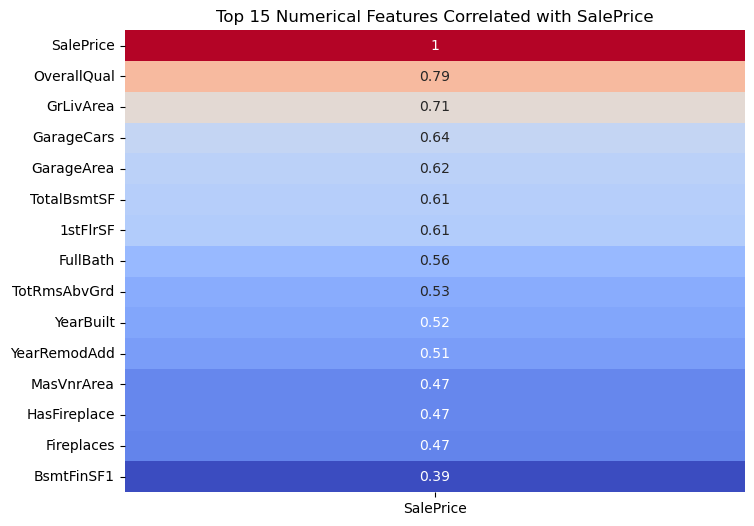

In [412]:
# identify which numerical features most strongly influence house prices
num_cols = train.select_dtypes(include=['int64','float64']).columns

corr = train[num_cols].corr()['SalePrice'].sort_values(ascending=False).head(15)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr.to_frame(), annot=True,cmap='coolwarm', cbar=False)
plt.title("Top 15 Numerical Features Correlated with SalePrice")
plt.show()

* The correlation analysis reveals that `OverallQual` 0.79 is the most influential factor in determining house prices, followed by `GrLivArea` 0.71, `GarageCars` 0.64, and `TotalBsmtSF` 0.61.
* This shows that both the quality of the house and its size are key drivers of value.
* Functional features such as `FullBath` 0.56 and `TotRmsAbvGrd` 0.53 also matter, while features like `fireplaces` 0.47 and `MasVnrArea` 0.48 provide additional but smaller contributions.
* Age-related variables `YearBuilt` 0.52 and `YearRemodAdd` 0.51 highlight the importance of newer or remodeled homes.

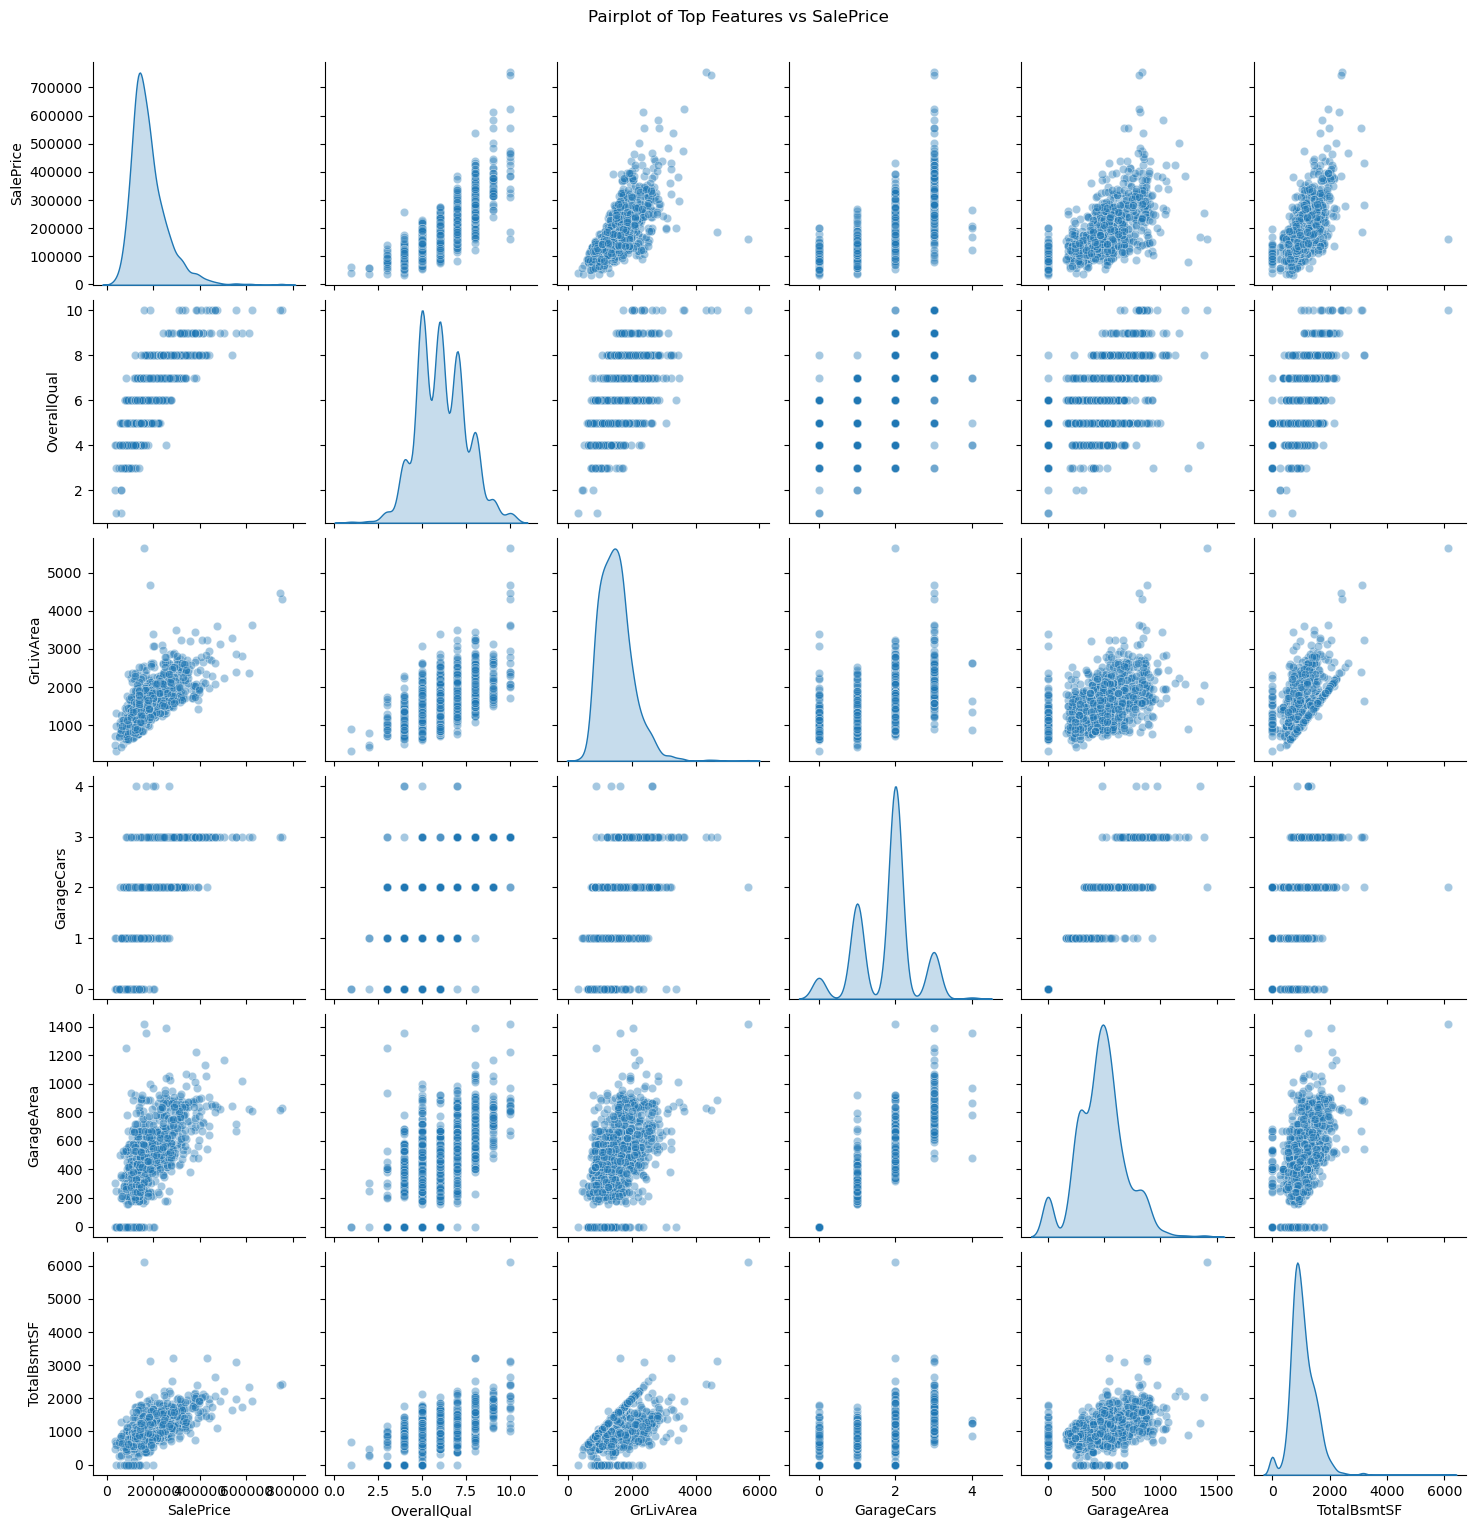

In [413]:
# Select top correlated features
top_features = ['SalePrice','OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF']

# Plot pairwise relationships in top_features
sns.pairplot(train[top_features], diag_kind='kde', plot_kws={'alpha':0.4})
plt.suptitle("Pairplot of Top Features vs SalePrice", y=1.02)
plt.show()


**Observations**
* The distribution of `SalePrice` and `GrLivArea` is right‑skewed, with a long tail toward higher values.
* `OverallQual` shows step‑wise jumps in `SalePrice`, acting almost like a categorical driver of value.
* `GrLivArea` has a strong linear relationship with `SalePrice`, but with clear outliers.
* `GarageCars` correlates well with `SalePrice`, though the effect plateaus after 3 cars.
* `GarageArea` overlaps heavily with `GarageCars`, indicating redundancy.
* `TotalBsmtSF` adds value but with more spread compared to above‑ground living area.
* Distributions of `SalePrice` and `GrLivArea` are right‑skewed.

**insight**
- Quality dominates size: Buyers pay more for `OverallQual` than raw square footage.
- Collinearity risk: `GarageCars` and `GarageArea` measure similar concepts; including both may inflate variance.
- Interaction effects: High quality amplifies the effect of size. small but high‑quality homes can outperform large low‑quality ones.
- Non‑linear thresholds: Garage capacity shows diminishing returns.
- Outlier influence: Large homes with low prices highlight market anomalies, possibly due to neighborhood or condition factors.
- Skewness matters: Skewed distributions can distort models.

**decision**
- Feature engineering
    - Create QualitySize Interaction.
    - Build EffectiveAge.
    - Normalize basement area.
- investigate outliers and skewness `GrLivArea`
- Apply a log transformation to `SalePrice` and `GrLivArea`
- **statistic**: calculating the skewness may be this help to more understand

In [414]:
# to make sure with statistic by calculating the skewness
num_cols = train.select_dtypes(include=['int64','float64']).columns

# Calculate skewness for each numeric column
skew_values = train[num_cols].skew().sort_values(ascending=False)
print(skew_values.head(25))

MiscVal                24.476794
PoolArea               14.828374
LotArea                12.207688
3SsnPorch              10.304342
LowQualFinSF            9.011341
KitchenAbvGr            4.488397
BsmtFinSF2              4.255261
ScreenPorch             4.122214
BsmtHalfBath            4.103403
HasGarage               3.887735
HasAlley                3.624557
EnclosedPorch           3.089872
MasVnrArea              2.677616
LotFrontage             2.409147
OpenPorchSF             2.364342
SalePrice               1.882876
LotFrontage_missing     1.690737
BsmtFinSF1              1.685503
WoodDeckSF              1.541376
TotalBsmtSF             1.524255
MSSubClass              1.407657
1stFlrSF                1.376757
GrLivArea               1.366560
BsmtUnfSF               0.920268
2ndFlrSF                0.813030
dtype: float64


**decision:**
- ignore Extremely skewed features because they are Low predictive power and may be adds noise

`MiscVal`,`PoolArea`,`LotArea`,`3SsnPorch`,`LowQualFinSF`,`KitchenAbvGr`,`smtFinSF2`,`creenPorch`,`smtHalfBath`           
- apply log transformation

`SalePrice`, `LotArea`,`GrLivArea`,`TotalBsmtSF`,`1stFlrSF`,`MasVnrArea`,`BsmtFinSF1`,`LotFrontage`

In [415]:
train["MSSubClass"].dtypes

dtype('int64')

In [416]:
train["MSSubClass"].head()

0    60
1    20
2    60
3    70
4    60
Name: MSSubClass, dtype: int64

`MSSubClass` it's special catagorical but data type is int so need to convert to catagory

In [417]:
train['MSSubClass'] = train['MSSubClass'].astype(str)

In [418]:
train['MSSubClass'].dtypes

dtype('O')

**treted as catagorical it prevent's wrong assumptions by model**

2.catagorical features with target variable

In [419]:
catagorical

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType',
       'SaleCondition'],
      dtype='object')

I inspected all categorical features but only present grouped plots for those most relevant to SalePrice.

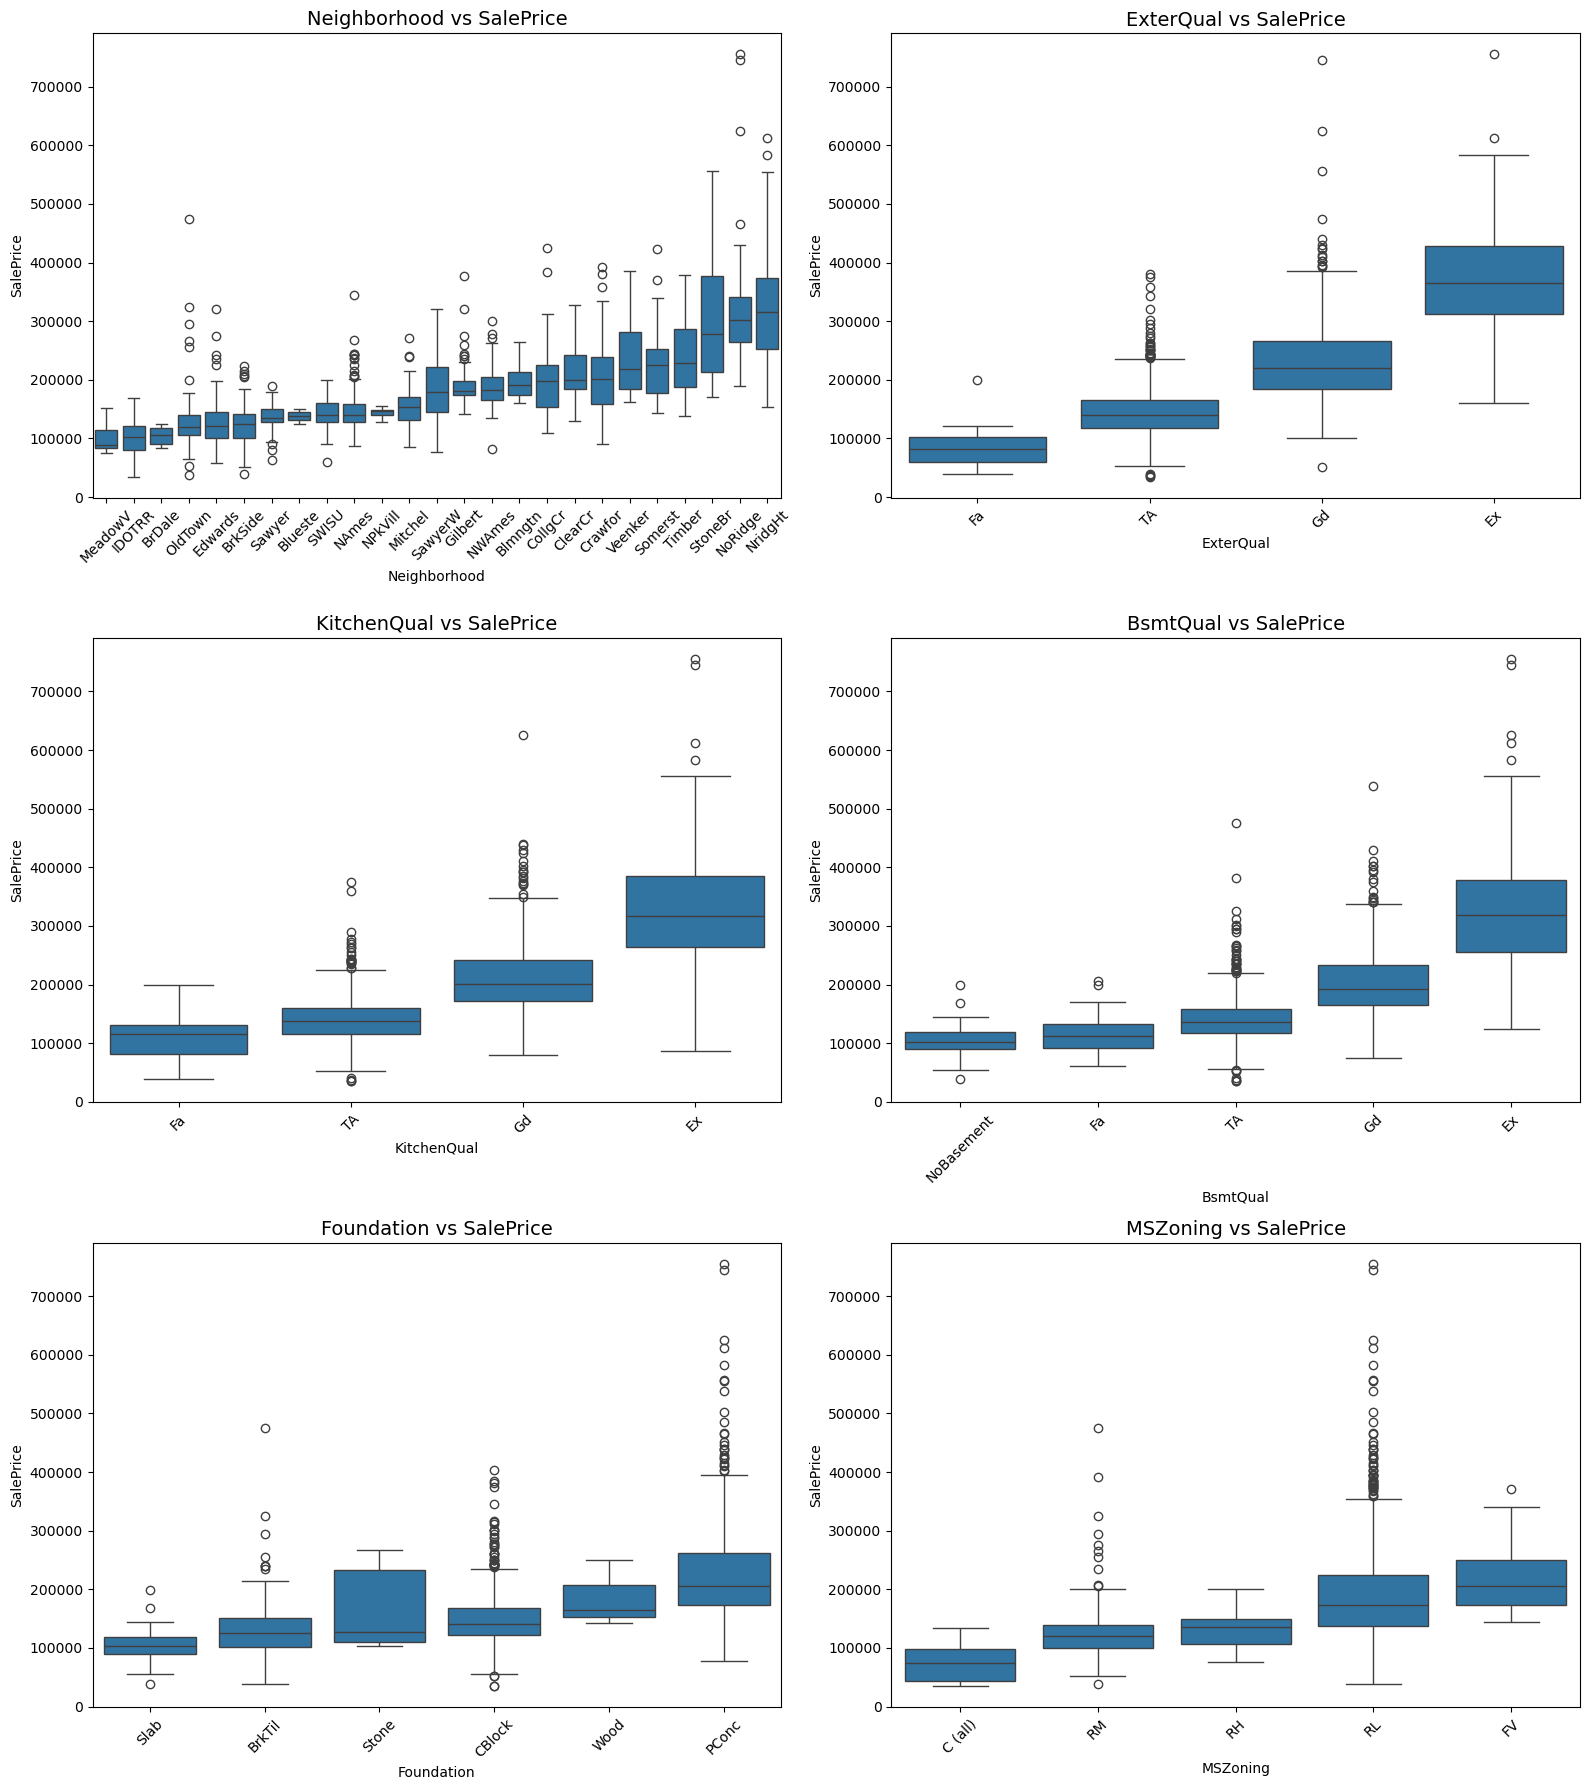

In [420]:
# top 6 Most Predictive Categorical Features

top_cats = ['Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual', 'Foundation', 'MSZoning']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(top_cats):
    order = train.groupby(col)['SalePrice'].median().sort_values().index
    
    sns.boxplot(x=col, y='SalePrice', data=train, ax=axes[i], order=order)
    axes[i].set_title(f'{col} vs SalePrice', fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Observations**
- Neighborhood: Median sale prices vary widely; premium neighborhoods consistently show higher values.
- ExterQual: Exterior quality ratings Fa, TA, Gd, Ex show a clear upward trend in sale price.
- KitchenQual: Kitchen quality strongly differentiates prices; Ex kitchens command a significant premium.
- BsmtQual: Basement quality impacts price, with Ex basements linked to higher values than TA or Fa.
- Foundation: Certain foundation types PConc are associated with higher prices compared to others.
- MSZoning: Zoning categories influence price; RL zones generally have higher sale prices than RM or C(all).

**Insights**
- Location premium: Neighborhood is one of the strongest categorical predictors, capturing geographic desirability.
- Quality matters: ExterQual, KitchenQual, and BsmtQual highlight how craftsmanship and condition directly drive value.
- Structural influence: Foundation type reflects durability and desirability, indirectly affecting price.
- Zoning impact: Land use restrictions MSZoning influence demand and price levels.
- Ordinal vs nominal distinction: Quality features are ordered, while neighborhood, foundation, and zoning are unordered or nominal.

**Decisions**
- Encode ordinal features ExterQual, KitchenQual, BsmtQual with ordered numeric mappings Po=1, Fa=2, TA=3, Gd=4, Ex=5.
- One‑hot encode nominal features Foundation, MSZoning to capture differences without imposing order.
- Group rare categories into Other to avoid sparse dummy variables.
- Feature engineering: Consider interaction terms like Neighborhood × OverallQual to capture location‑quality effects.

## Features Relationships
- detect redundancy
- detect multicollinearity
- uncover useful interactions

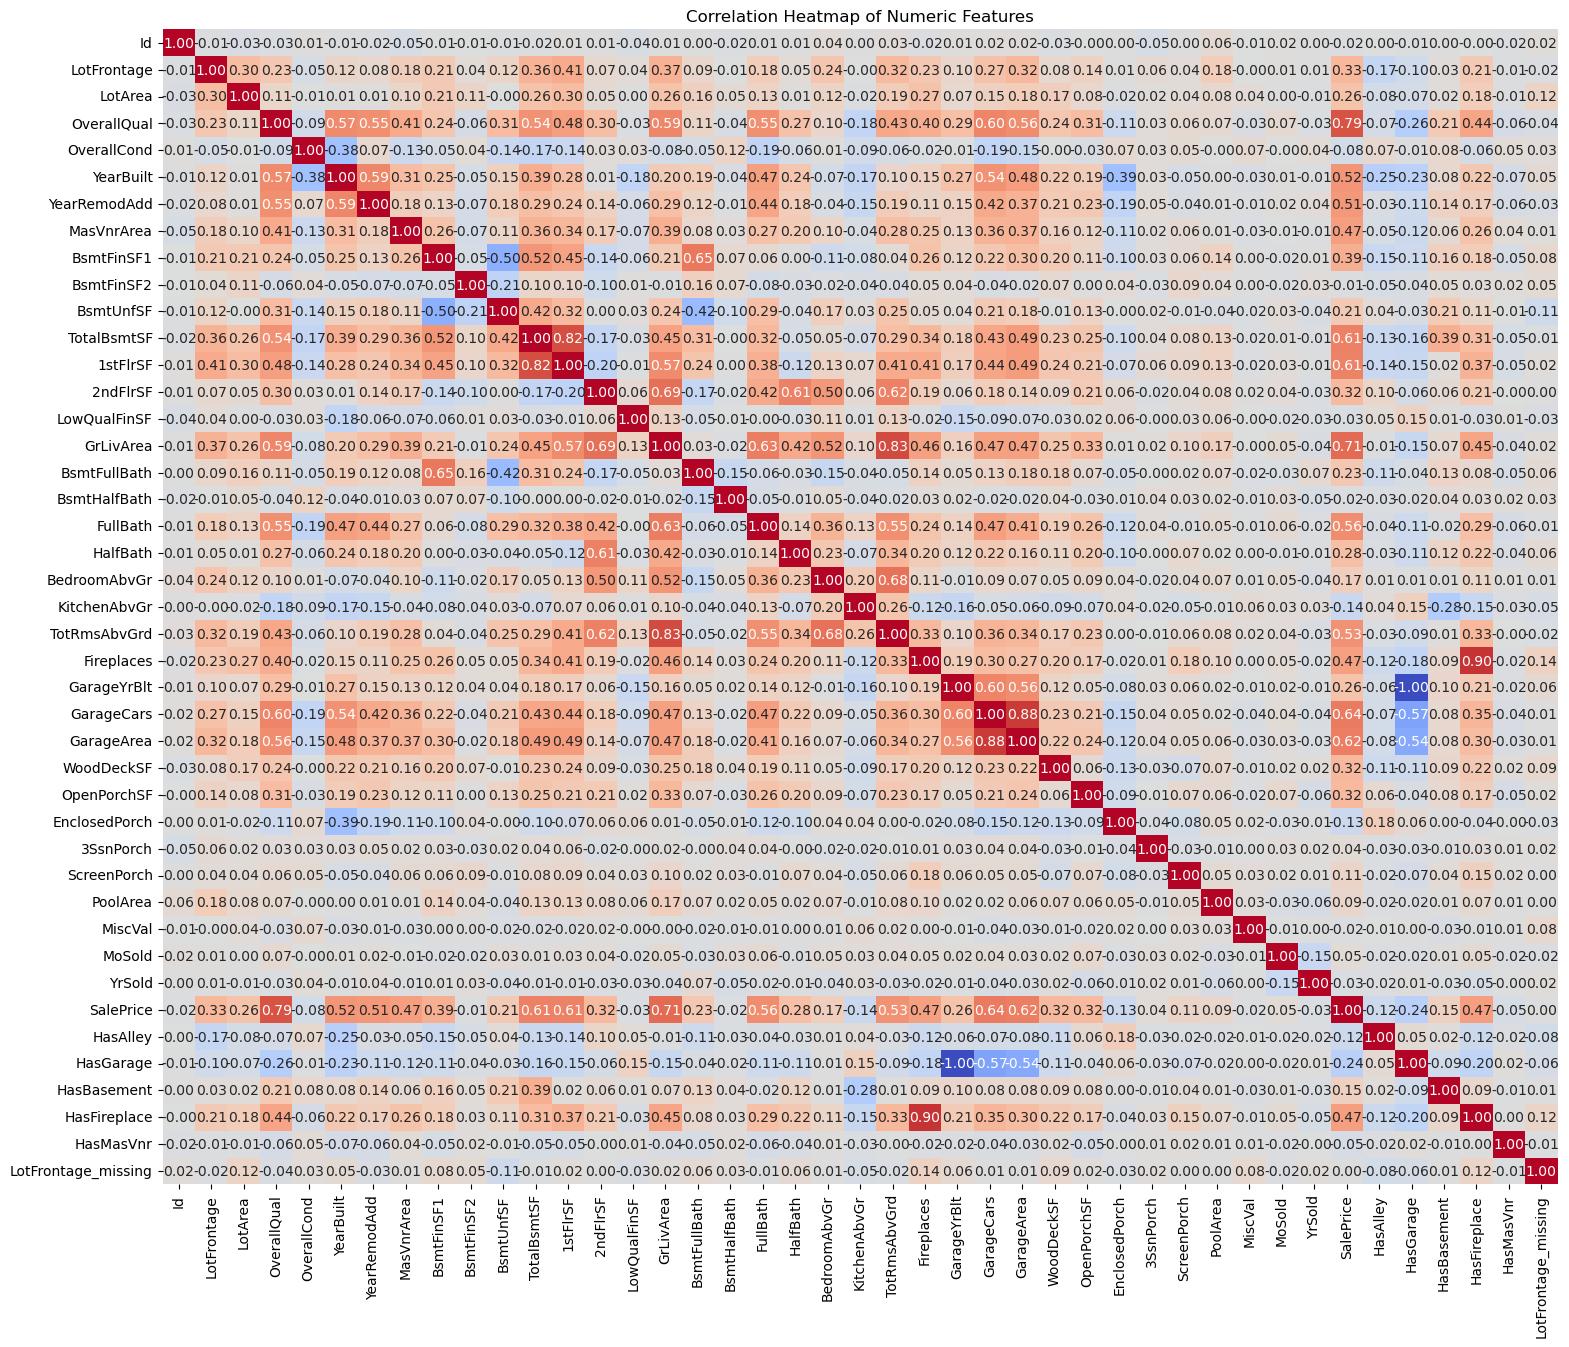

In [421]:
# Correlation heatmap for numeric features
corr_matrix = train.corr(numeric_only=True)
plt.figure(figsize=(18,15))
sns.heatmap(corr_matrix,annot=True,cbar=False,fmt='.2f',cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

my correlation heatmap is a bit large hard to check all so, i detect strongly correlated feature pairs programmatically.
This approach highlights only the relationships above 0.8, making it easier to spot redundancy and multicollinearity.

In [422]:
# Extract pairs with correlation > 0.8

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_val = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, corr_val))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature1", "Feature2", "Correlation"])
high_corr_df.sort_values("Correlation", ascending=False)


,Feature1,Feature2,Correlation
2,Fireplaces,HasFireplace,0.900457
4,GarageCars,GarageArea,0.882475
1,GrLivArea,TotRmsAbvGrd,0.825489
0,TotalBsmtSF,1stFlrSF,0.819530
3,GarageYrBlt,HasGarage,-0.998601


- The correlation heatmap shows relationships among all numeric features.
- Strong correlations indicate multicollinearity.
- Multicollinearity can cause instability in regression models, making coefficients unreliable.
- Features like `GarageArea` vs `GarageCars`, or `GrLivArea` vs `TotRmsAbvGrd`, often overlap in the information they provide.

**decision:**
- combine redundant features to reduce noise
- drop 	GarageYrBlt	


In [423]:
train["YrSold"].value_counts()

YrSold
2009    338
2007    329
2006    314
2008    304
2010    175
Name: count, dtype: int64

In [424]:
train["YearBuilt"].value_counts()

YearBuilt
2006    67
2005    64
2004    54
2007    49
2003    45
        ..
1875     1
1911     1
1917     1
1872     1
1905     1
Name: count, Length: 112, dtype: int64

In [425]:
train["YearBuilt"].min()

1872

**observation**
- Houses span from 1872 to 2007, with 112 unique build years.
- The 2000s dominate 
- Very old houses  appear only once each year, making them rare outliers.

**decision**
- Create HouseAge = `YrSold – YearBuilt` to capture property age at sale.
- Bin years into eras for categorical clarity and to reduce sparsity:
   - Historic (<1950)
   - Mid‑century (1950–1980)
   - Modern (1980–2000)
   - Recent (2000+)

In [426]:
# count number of Neighborhoods
train['Neighborhood'].value_counts()

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

In [427]:
# compare Neighborhood and HouseStyle
pd.crosstab(train['Neighborhood'], train['HouseStyle'])

HouseStyle,1.5Fin,1.5Unf,1Story,2.5Fin,2.5Unf,2Story,SFoyer,SLvl
Neighborhood,,,,,,,,
Blmngtn,0,0,17,0,0,0,0,0
Blueste,0,0,0,0,0,2,0,0
BrDale,0,0,0,0,0,16,0,0
BrkSide,25,6,20,0,1,6,0,0
ClearCr,6,0,11,0,0,8,0,3
CollgCr,0,0,91,0,0,53,3,3
Crawfor,9,1,19,1,1,20,0,0
Edwards,22,0,53,0,0,14,5,6
Gilbert,1,0,11,0,0,60,0,7


**Observation**
- The cross‑tabulation shows how different house styles are distributed across neighborhoods.
- a lot of zeros this indicates that most neighborhoods do not have every house style
- Certain neighborhoods are dominated by a single house style:
     - **NAmes**  overwhelmingly `1Story` 159 out of 225.
     - **Gilbert**  strongly `2Story` 60 out of 79.
     - **BrDale**  almost exclusively `2Story` 16 out of 16.
- Other neighborhoods show more diversity:
     - **BrkSide** mix of `1.5Fin`, `1.5Unf`, `1Story`, and `2Story`.
     - **OldTown** wide spread across `1Story`, `2Story`, `2.5Fin`, `2.5Unf`
- Rare combinations exist `2.5Fin` in **OldTown** and **SWISU** `SFoyer` in **Edwards** and **MeadowV** which appear only a handful of times.

**insight**
- style and neighborhood are so closely linked
- Neighborhoods with diverse distributions like OldTown, BrkSide provide richer information and may capture more variation in housing patterns.
- Rare categories like `2.5Fin`, `SFoyer` in small neighborhoods may lead to sparse data issues and unstable estimates.

**decision**
- Group low-frequency HouseStyle into broader buckets.
    - Combine `2.5Fin`, `2.5Unf` into a "2.5_Story".
    - Combine `1.5Unf` and `1.5Fin` into "1.5_Story".
    - Combine `SFoyer` and `SLvl` into "Split_Level".
- Create a boolean feature called `Is_Standard_Style`
- Target Encoding for `Neighborhood` with Median SalePrice of that neighborhood. i do this because One‑Hot Encoding is increase the dimension greatly
- One‑Hot Encoding for `HouseStyle` after combining 

In [428]:
# compare Neighborhood and HouseStyle
pd.crosstab(train['Neighborhood'], train['OverallQual'])

OverallQual,1,2,3,4,5,6,7,8,9,10
Neighborhood,,,,,,,,,,
Blmngtn,0,0,0,0,0,0,14,3,0,0
Blueste,0,0,0,0,0,2,0,0,0,0
BrDale,0,0,0,0,5,11,0,0,0,0
BrkSide,1,1,3,10,21,18,4,0,0,0
ClearCr,0,0,0,3,6,10,9,0,0,0
CollgCr,0,0,0,1,28,24,71,23,3,0
Crawfor,0,0,0,1,11,19,13,7,0,0
Edwards,1,0,5,25,38,23,5,0,1,2
Gilbert,0,0,0,1,3,33,36,5,1,0


* Some neighborhoods are dominated by mid‑range quality

   - NAmes mostly 5 and 6.
   - Sawyer heavily concentrated in 5.
   - Edwards spread across 4–6, with few higher ratings.
* Other neighborhoods lean toward higher quality
  
  - NoRidge concentrated in 7–10.
  - NridgHt strong presence in 7–9.
  - StoneBr and Timber mostly 7–8.
*  A few neighborhoods show low quality dominance

   - BrkSide many houses rated 4–5.
   - MeadowV mostly 4–5.
   - IDOTRR spread across 3–5.

**Insight**

- There is a clear dependency between neighborhood and overall quality
- neighborhoods NoRidge, NridgHt, StoneBr tend to have higher quality homes.
- Older or lower‑income neighborhoods BrkSide, MeadowV, IDOTRR show lower quality ratings.

In [429]:
# crosstab of exterior quality and kitchen quality
pd.crosstab(train['ExterQual'], train['KitchenQual'])

KitchenQual,Ex,Fa,Gd,TA
ExterQual,,,,
Ex,42,0,8,2
Fa,0,8,0,6
Gd,47,0,408,33
TA,11,31,170,694


Most houses fall into consistent pairings:
- ExterQual = Gd  overwhelmingly KitchenQual = Gd with 408 cases.
- ExterQual = TA  mostly KitchenQual = TA with 694 cases.
- High‑quality exteriors (Ex) often coincide with high‑quality kitchens Ex = 42 cases.
- Lower‑quality exteriors (Fa) align with lower‑quality kitchens Fa = 8 cases.

**Insight:** A house with an Excellent Exterior but only Fair Kitchen is often a flip or a house with neglected interiors. In real estate, this quality gap usually results in a price penalty because buyers feel the interior as a project that requires additional investment.

In [430]:
# building types distribute across zoning classifications
pd.crosstab(train['MSZoning'], train['BldgType'])

BldgType,1Fam,2fmCon,Duplex,Twnhs,TwnhsE
MSZoning,,,,,
C (all),9,1,0,0,0
FV,38,0,0,9,18
RH,9,2,3,0,2
RL,1025,16,43,10,57
RM,139,12,6,24,37


**observation**

MSZoning and BldgType are strongly related, but their joint effect matters more than either alone
- `C (all)` zoning is rare, with only 9 single‑family and 1 two‑family conversion.
- `FV` zoning shows a mix of single‑family homes (38) and townhouse end units (18).
- `RH` zoning includes a spread across 2fmCon, Duplex, and TwnhsE, though in smaller numbers.
- `RL` zoning overwhelmingly contains `1Fam` = 1025, with smaller counts of duplexes and townhouses.
- `RM` zoning is more diverse, with notable counts of townhouses (24) and townhouse end units (37).

**Insight:** The value of building type is heavily modified by the Zoning. A single-family home in `C (all)` is actually a risk, surrounded by commercial activity, reducing livability and a single‑family home in `RL` zoning is desirable because it aligns with suburban residential expectations.

**decision**
- Create a Privacy Index feature:
   - High Privacy = `1Fam` + `RL`
   - Medium Privacy =`TwnhsE` + `RL`
   - Low Privacy = `Duplex` + `2fmCon`
- Encode as an ordinal feature 

## Feature Engineering
this Feature Engineering is **based on exploration and decision in EDA** nothing is in Random

In [431]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Alley',
       'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'Exterior1st', 'Exterior2nd',
       'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', 

In [432]:
# HouseStyle Grouping
common_styles = ['1Story', '2Story']

train['HouseStyle_Grouped'] = train['HouseStyle'].apply(
    lambda x: x if x in common_styles else 'Other'
)
train.drop("HouseStyle",axis=1,inplace=True)

In [433]:
def privacy_index(row):
    if row['BldgType'] == '1Fam' and row['MSZoning'] == 'RL':
        return 3 
    elif row['BldgType'] == 'TwnhsE' and row['MSZoning'] == 'RL':
        return 2  
    elif row['BldgType'] in ['Duplex', '2fmCon']:
        return 1  
    else:
        return 0  

train['PrivacyIndex'] = train.apply(privacy_index, axis=1)

In [434]:
# Foundation grouping
common_foundations = ['PConc', 'CBlock']
train['Foundation_Grouped'] = train['Foundation'].where(train['Foundation'].isin(common_foundations), 'Other')

# Zoning grouping
rare_zones = train['MSZoning'].value_counts()[train['MSZoning'].value_counts() < 50].index
train['MSZoning_Simplified'] = train['MSZoning'].replace(dict.fromkeys(rare_zones, 'Rare'))

train = train.drop(['MSZoning', 'Foundation',], axis=1)

In [435]:
# Exterior1st Simplification
top_exterior = train['Exterior1st'].value_counts().nlargest(3).index

train['Exterior1st_Grouped'] = train['Exterior1st'].apply(
    lambda x: x if x in top_exterior else 'Other'
)
train.drop("Exterior1st",axis=1,inplace=True)

In [436]:
# GarageType grouping
common_garage = ['Attchd', 'Detchd']

train['GarageType_Grouped'] = train['GarageType'].apply(
    lambda x: x if x in common_garage else 'Other'
)
train.drop("GarageType",axis=1,inplace=True)

In [437]:
# SaleCondition Grouping
train['SaleCondition_Grouped'] = train['SaleCondition'].apply(
    lambda x: 'Normal' if x == 'Normal' else 'Abnormal'
)
train.drop("SaleCondition",axis=1,inplace=True)

Captures whether a house follows mainstream design patterns.

In [438]:
# Neighborhood Target Encoding
neighborhood_map = train.groupby('Neighborhood')['SalePrice'].median()
train['Neighborhood_price'] = train['Neighborhood'].map(neighborhood_map)

Preserves neighborhood-level price signal without exploding dimensions.

In [439]:
# Quality × Neighborhood Interaction 
train['Neigh_Qual'] = train['OverallQual'] * train['Neighborhood_price']

Captures how quality distribution differs by location.

In [440]:
# combining exterior and kitchen quality.
train['Qual_Combo'] = train['ExterQual'].astype(str) + '_' + train['KitchenQual'].astype(str)

Captures joint material/finish quality signal

In [441]:
def year_to_era(year):
    if year < 1950:
        return 'Historic'
    elif year < 1980:
        return 'MidCentury'
    elif year < 2000:
        return 'Modern'
    else:
        return 'Recent'

train['HouseEra'] = train['YearBuilt'].apply(year_to_era)

In [442]:
# Detect Anomalies
train['PricePerSF'] = train['SalePrice'] / (train['GrLivArea'] + 1)

In [443]:
# Time-Based Features
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
train['IsRemodeled'] = (train['YearBuilt'] != train['YearRemodAdd']).astype(int)

In [444]:
# Combine Sparse Features
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
train['TotalBathrooms'] = (
    train['FullBath'] +
    0.5 * train['HalfBath'] +
    train['BsmtFullBath'] +
    0.5 * train['BsmtHalfBath']
)

train['TotalPorchSF'] = (
    train['OpenPorchSF'] +
    train['EnclosedPorch'] +
    train['3SsnPorch'] +
    train['ScreenPorch']
)

In [445]:
# Quality & Condition Combinations
train['TotalQual'] = train['OverallQual'] + train['OverallCond']
train['QualSize'] = train['OverallQual'] * train['GrLivArea']

In [446]:
# Handling Garage Features Redundancy

train['GarageAge'] = train['YrSold'] - train['GarageYrBlt']
train['GarageScore'] = train['GarageCars'] * train['GarageArea']
train = train.drop(['GarageArea'], axis=1)

* Captures both capacity + size
* Removes collinearity

In [447]:
# Capture Diminishing Returns(plateau after 3 cars)

train['GarageCars_capped'] = train['GarageCars'].clip(upper=3)

In [448]:
# Basement Features
train['TotalBsmtFinSF'] = train['BsmtFinSF1'] + train['BsmtFinSF2']
train['BsmtRatio'] = train['TotalBsmtSF'] / (train['1stFlrSF'] + 1)

Finished basement adds real living value

In [449]:
# Density / Efficiency Features
train['RoomsPerArea'] = train['TotRmsAbvGrd'] / (train['GrLivArea'] + 1)
train = train.drop('TotRmsAbvGrd', axis=1)

train['BathPerBedroom'] = train['TotalBathrooms'] / (train['BedroomAbvGr'] + 1)

Let's Visualize Our `MasVnrArea`, `GrLivArea`, `LotArea` columns for Outliers 

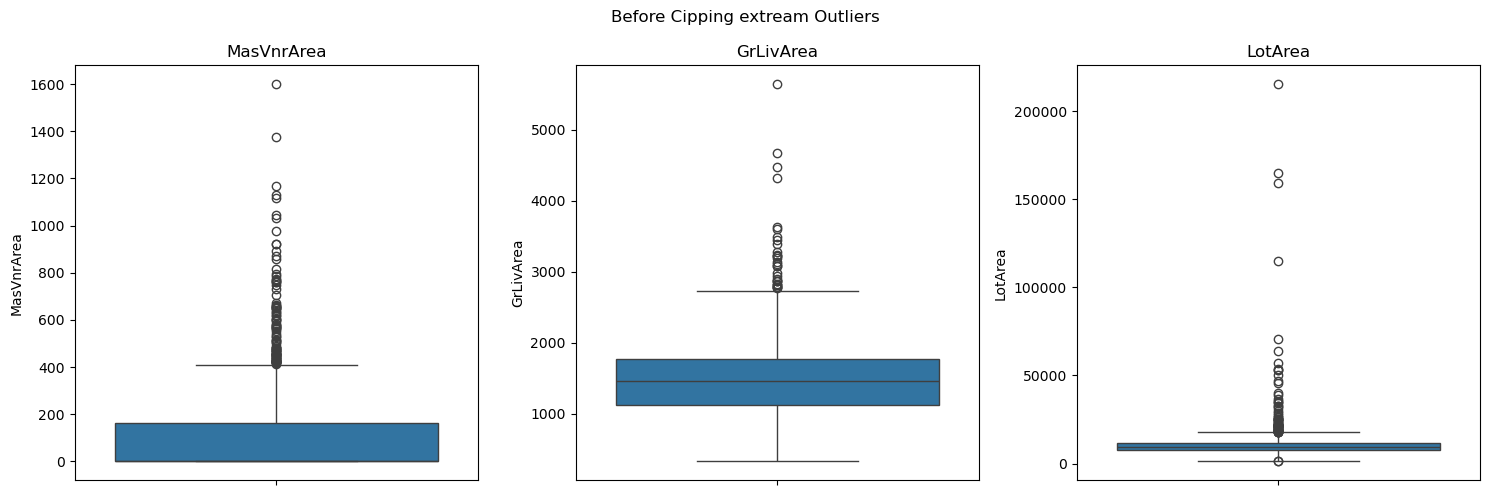

In [450]:
cols = ['MasVnrArea', 'GrLivArea', 'LotArea'] 

plt.figure(figsize=(15,5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=train[col])
    plt.title(col)
plt.suptitle("Before Cipping extream Outliers")
plt.tight_layout()
plt.show()

In [451]:
# Outlier Handling
for col in ['LotArea', 'GrLivArea', 'MasVnrArea']:
    lower = train[col].quantile(0.01)
    upper = train[col].quantile(0.99)
    train[col] = train[col].clip(lower, upper)

In [452]:
# Remove extreme outliers
train = train[train['GrLivArea'] < 4000]

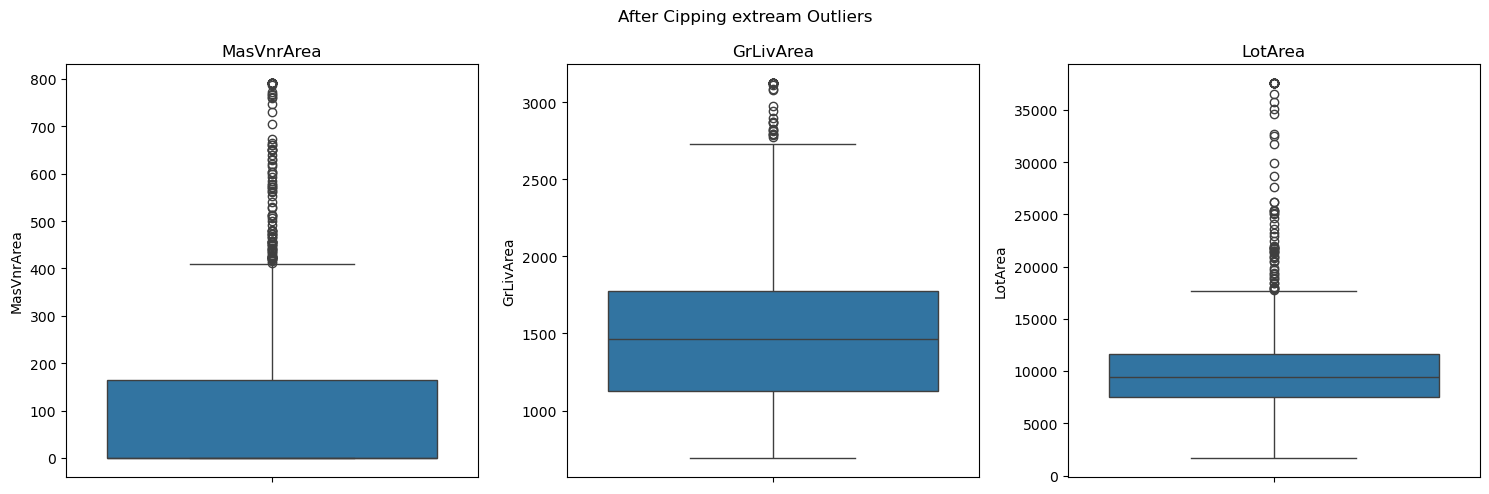

In [453]:
cols = ['MasVnrArea', 'GrLivArea', 'LotArea']
plt.figure(figsize=(15,5))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=train[col])
    plt.title(col)
plt.suptitle("After Cipping extream Outliers")

plt.tight_layout()
plt.show()

In [454]:
# Define threshold
threshold = 20
neigh_counts = train['Neighborhood'].value_counts()

# Identify rare neighborhoods
rare_neigh = neigh_counts[neigh_counts < threshold].index
train['Neighborhood_Grouped'] = train['Neighborhood'].replace(rare_neigh, 'Other')

In [455]:
# Target Transformation
train['SalePrice'] = np.log1p(train['SalePrice'])

In [456]:
# Log Transform

skewed_cols = [
    'LotArea', 'GrLivArea', 'MasVnrArea', 'TotalBsmtSF',
    '1stFlrSF', '2ndFlrSF', 'LotFrontage',
    'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch','BsmtFinSF1'
]
for col in skewed_cols:
    train[col] = np.log1p(train[col])

- Reduces long tails
- Stabilizes variance

In [457]:
log_cols = skewed_cols
train[log_cols].describe()

,LotArea,GrLivArea,MasVnrArea,TotalBsmtSF,1stFlrSF,2ndFlrSF,LotFrontage,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,BsmtFinSF1
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,9.105220,7.268696,2.117703,6.750560,7.008452,2.864586,4.214451,2.457206,2.308541,0.698019,0.085679,0.410671,4.229731
std,0.490715,0.323275,2.624122,1.145712,0.317431,3.293311,0.314395,2.596435,2.152387,1.727317,0.666876,1.403194,2.992052
min,7.427144,6.541290,0.000000,0.000000,5.814131,0.000000,3.091042,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.929898,7.030415,0.000000,6.680541,6.783325,0.000000,4.110874,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.156887,7.289611,0.000000,6.900227,6.992096,0.000000,4.248495,0.000000,3.258097,0.000000,0.000000,0.000000,5.951943
75%,9.358976,7.483104,5.107456,7.169542,7.238676,6.591674,4.382027,5.129899,4.234107,0.000000,0.000000,0.000000,6.569832
max,10.533925,8.047023,6.674915,8.717846,8.453827,7.633370,5.749393,6.754604,6.306275,6.315358,6.232448,6.175867,8.638525


Before transformation: distributions were heavily right‑tailed, which can bias regression models and inflate error terms.

After transformation: the summary statistics (mean, std, min, max) are compressed, and extreme values are reduced in scale.
- Outliers are less influential.
- Relationships between predictors and target become more linear.
- Model assumptions (normality of residuals, homoscedasticity) are better satisfied.
- LotArea mean reduced from ~10.5 raw scale to ~9.1 log scale.
- GrLivArea compressed from ~8.0 max to ~7.26 mean.

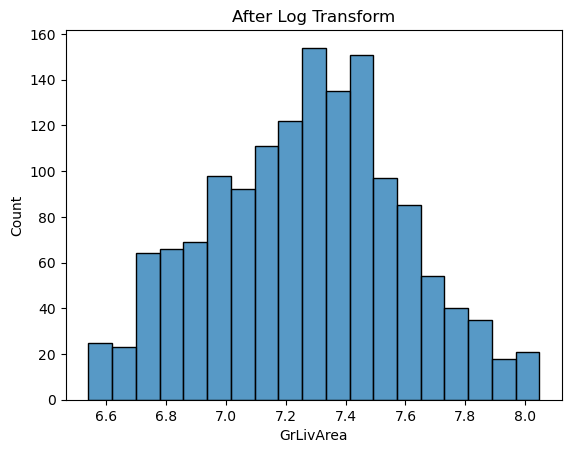

In [458]:
sns.histplot(data=train, x='GrLivArea')
plt.title("After Log Transform")
plt.xlabel("GrLivArea")
plt.ylabel("Count")
plt.show()

In [459]:
cat_cols = train.select_dtypes(exclude=['int64','float64']).columns
cat_cols

Index(['MSSubClass', 'Alley', 'LotShape', 'LandContour', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'RoofStyle',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'Fence', 'SaleType', 'HouseStyle_Grouped', 'Foundation_Grouped',
       'MSZoning_Simplified', 'Exterior1st_Grouped', 'GarageType_Grouped',
       'SaleCondition_Grouped', 'Qual_Combo', 'HouseEra',
       'Neighborhood_Grouped'],
      dtype='object')

In [460]:
# Ordinal features
ordinal_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond',
    'KitchenQual', 'HeatingQC',
    'GarageQual', 'GarageCond',
    'FireplaceQu'
]

ordinal_categories = [
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                     # ExterQual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                     # ExterCond
    ['NoBasement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],       # BsmtQual
    ['NoBasement', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],       # BsmtCond
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                     # KitchenQual
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],                     # HeatingQC
    ['NoGarage', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],         # GarageQual
    ['NoGarage', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],         # GarageCond
    ['NoFireplace', 'Po', 'Fa', 'TA', 'Gd', 'Ex']       # FireplaceQu
]

nominal_cols = [
    'MSSubClass', 'Alley', 'LotShape', 'LandContour', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'RoofStyle',
    'Exterior2nd', 'MasVnrType', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional',
    'PavedDrive', 'Fence', 'SaleType',
    'HouseStyle_Grouped', 'Foundation_Grouped',
    'MSZoning_Simplified', 'Exterior1st_Grouped',
    'GarageType_Grouped', 'SaleCondition_Grouped'
]

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1)
    
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', ordinal_encoder, ordinal_cols),
        ('nom', OneHotEncoder(handle_unknown='ignore', drop='first'), nominal_cols)
    ],
    remainder='passthrough'
)
train_processed = preprocessor.fit_transform(train)

In [461]:
feature_names = preprocessor.get_feature_names_out()

train_processed_df = pd.DataFrame(
    train_processed.toarray() if hasattr(train_processed, "toarray") else train_processed,
    columns=feature_names
)


In [462]:
train_processed_df.head()

,ord__ExterQual,ord__ExterCond,ord__BsmtQual,ord__BsmtCond,ord__KitchenQual,ord__HeatingQC,ord__GarageQual,ord__GarageCond,ord__FireplaceQu,nom__MSSubClass_160,nom__MSSubClass_180,nom__MSSubClass_190,nom__MSSubClass_20,nom__MSSubClass_30,nom__MSSubClass_40,nom__MSSubClass_45,nom__MSSubClass_50,nom__MSSubClass_60,nom__MSSubClass_70,nom__MSSubClass_75,nom__MSSubClass_80,nom__MSSubClass_85,nom__MSSubClass_90,nom__Alley_NoAlley,nom__Alley_Pave,nom__LotShape_IR2,nom__LotShape_IR3,nom__LotShape_Reg,nom__LandContour_HLS,nom__LandContour_Low,nom__LandContour_Lvl,nom__LotConfig_CulDSac,nom__LotConfig_FR2,nom__LotConfig_FR3,nom__LotConfig_Inside,nom__LandSlope_Mod,nom__LandSlope_Sev,nom__Neighborhood_Blueste,nom__Neighborhood_BrDale,nom__Neighborhood_BrkSide,nom__Neighborhood_ClearCr,nom__Neighborhood_CollgCr,nom__Neighborhood_Crawfor,nom__Neighborhood_Edwards,nom__Neighborhood_Gilbert,nom__Neighborhood_IDOTRR,nom__Neighborhood_MeadowV,nom__Neighborhood_Mitchel,nom__Neighborhood_NAmes,nom__Neighborhood_NPkVill,nom__Neighborhood_NWAmes,nom__Neighborhood_NoRidge,nom__Neighborhood_NridgHt,nom__Neighborhood_OldTown,nom__Neighborhood_SWISU,nom__Neighborhood_Sawyer,nom__Neighborhood_SawyerW,nom__Neighborhood_Somerst,nom__Neighborhood_StoneBr,nom__Neighborhood_Timber,nom__Neighborhood_Veenker,nom__Condition1_Feedr,nom__Condition1_Norm,nom__Condition1_PosA,nom__Condition1_PosN,nom__Condition1_RRAe,nom__Condition1_RRAn,nom__Condition1_RRNe,nom__Condition1_RRNn,nom__BldgType_2fmCon,nom__BldgType_Duplex,nom__BldgType_Twnhs,nom__BldgType_TwnhsE,nom__RoofStyle_Gable,nom__RoofStyle_Gambrel,nom__RoofStyle_Hip,nom__RoofStyle_Mansard,nom__RoofStyle_Shed,nom__Exterior2nd_AsphShn,nom__Exterior2nd_Brk Cmn,nom__Exterior2nd_BrkFace,nom__Exterior2nd_CBlock,nom__Exterior2nd_CmentBd,nom__Exterior2nd_HdBoard,nom__Exterior2nd_ImStucc,nom__Exterior2nd_MetalSd,nom__Exterior2nd_Other,nom__Exterior2nd_Plywood,nom__Exterior2nd_Stone,nom__Exterior2nd_Stucco,nom__Exterior2nd_VinylSd,nom__Exterior2nd_Wd Sdng,nom__Exterior2nd_Wd Shng,nom__MasVnrType_BrkFace,nom__MasVnrType_None,nom__MasVnrType_Stone,nom__BsmtExposure_Gd,nom__BsmtExposure_Mn,nom__BsmtExposure_No,nom__BsmtExposure_NoBasement,nom__BsmtFinType1_BLQ,nom__BsmtFinType1_GLQ,nom__BsmtFinType1_LwQ,nom__BsmtFinType1_NoBasement,nom__BsmtFinType1_Rec,nom__BsmtFinType1_Unf,nom__BsmtFinType2_BLQ,nom__BsmtFinType2_GLQ,nom__BsmtFinType2_LwQ,nom__BsmtFinType2_NoBasement,nom__BsmtFinType2_Rec,nom__BsmtFinType2_Unf,nom__Heating_GasA,nom__Heating_GasW,nom__Heating_Grav,nom__Heating_OthW,nom__Heating_Wall,nom__CentralAir_Y,nom__Electrical_FuseF,nom__Electrical_FuseP,nom__Electrical_Mix,nom__Electrical_SBrkr,nom__Functional_Maj2,nom__Functional_Min1,nom__Functional_Min2,nom__Functional_Mod,nom__Functional_Sev,nom__Functional_Typ,nom__PavedDrive_P,nom__PavedDrive_Y,nom__Fence_GdWo,nom__Fence_MnPrv,nom__Fence_MnWw,nom__Fence_NoFence,nom__SaleType_CWD,nom__SaleType_Con,nom__SaleType_ConLD,nom__SaleType_ConLI,nom__SaleType_ConLw,nom__SaleType_New,nom__SaleType_Oth,nom__SaleType_WD,nom__HouseStyle_Grouped_2Story,nom__HouseStyle_Grouped_Other,nom__Foundation_Grouped_Other,nom__Foundation_Grouped_PConc,nom__MSZoning_Simplified_RL,nom__MSZoning_Simplified_RM,nom__MSZoning_Simplified_Rare,nom__Exterior1st_Grouped_MetalSd,nom__Exterior1st_Grouped_Other,nom__Exterior1st_Grouped_VinylSd,nom__GarageType_Grouped_Detchd,nom__GarageType_Grouped_Other,nom__SaleCondition_Grouped_Normal,remainder__Id,remainder__LotFrontage,remainder__LotArea,remainder__OverallQual,remainder__OverallCond,remainder__YearBuilt,remainder__YearRemodAdd,remainder__MasVnrArea,remainder__BsmtFinSF1,remainder__BsmtFinSF2,remainder__BsmtUnfSF,remainder__TotalBsmtSF,remainder__1stFlrSF,remainder__2ndFlrSF,remainder__LowQualFinSF,remainder__GrLivArea,remainder__BsmtFullBath,remainder__BsmtHalfBath,remainder__FullBath,remainder__HalfBath,remainder__BedroomAbvGr,remainder__KitchenAbvGr,remainder__Fireplaces,remainder__GarageYrBlt,remainder__GarageFinish,remainder__GarageCars,r